# Playability Metric — is the tab *usable*, not just *exact*?

Companion to **`AudioToTabCAGED (2).ipynb`**. Exact-match TDR is 0.69, but the error analysis showed **96% of disagreements are single-string alternates** — the same pitch fingered one string over, a physically valid choice the human happened not to make. For a task with several correct answers, exact-match is the wrong yardstick. This notebook scores whether the produced tab is **playable** and compares it head-to-head with the expert ground-truth tab on the *same notes*.

**Method.** Loads the saved `audio_to_tab_matches.csv` (no re-run), groups matched notes into simultaneous **grips** by onset, then scores two things on identical groupings:
- **Physical validity** (hard): every grip's fretted span fits one hand and no two notes collide on one string.
- **Hand-movement & span** (soft): fret-jump between consecutive grips, large-jump rate, grip span — computed for the *predicted* tab and the *ground-truth* tab so the comparison is apples-to-apples.

**The argument it builds:** strict exact-match credits one of several valid fingerings and reports 0.69; but the predicted tabs are physically playable ~99% of the time and their movement/span profile matches expert ground truth — so the model produces playable, expert-comparable tablature. Exact-match understates it.

Scope note: this evaluates the **assignment layer** on correctly-detected notes (the matched subset), which is exactly where playability is decided. Detection is out of scope here by design.


## 1. Load matches + fretboard config

In [1]:
import pandas as pd, numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

AUDIO_OUTPUT_DIR = Path('/content/drive/MyDrive/Capstone/outputs/audio_to_tab_basic_pitch_heldout')  # EDIT if needed
MATCHES_CSV = AUDIO_OUTPUT_DIR / 'audio_to_tab_matches.csv'
assert MATCHES_CSV.exists(), f"Not found: {MATCHES_CSV} — run the eval cell in AudioToTabCAGED (2).ipynb first."

OPEN_STRING_MIDI = [40,45,50,55,59,64]
STRING_NAMES     = ['low_E','A','D','G','B','high_E']
MAX_FRET = 24

# Playability thresholds (transparent + adjustable)
ONSET_TOL = 0.05      # seconds: notes within this window = one grip
MAX_SPAN  = 5         # frets reachable in one hand position (4 = strict one-finger-per-fret, 5 = with stretch)
BIG_JUMP  = 4         # fret-jump above this = a real position shift

m = pd.read_csv(MATCHES_CSV)
def as_bool(s): return s.astype(str).str.lower().isin(['true','1','1.0'])
for c in ['exact_tab_correct','string_correct','fret_correct']:
    if c in m: m[c]=as_bool(m[c])
for c in ['pred_string','pred_fret','true_string','true_fret','midi','pred_start','gt_start']:
    if c in m: m[c]=pd.to_numeric(m[c], errors='coerce')
m['segment'] = np.where(m['recording'].astype(str).str.endswith('_solo'),'solo','comp')
print("Rows:", len(m), "| methods:", sorted(m['method'].dropna().unique()))

Mounted at /content/drive
Rows: 23004 | methods: ['caged_box', 'caged_voiced', 'combined_all_tuned']


## 2. Grip-grouping + playability scorers

Notes within `ONSET_TOL` form one grip. For a position assignment (`string`,`fret`):
- **fretted span** = max−min over fingered frets (fret>0; open strings need no finger),
- **duplicate-string** = two notes share a string (physically impossible),
- **grip playable** = span ≤ `MAX_SPAN` and no duplicate-string,
- **hand position** = mean fingered fret (anchor for movement),
- **fret-jump** = |Δ position| between consecutive grips; **large jump** > `BIG_JUMP`.

The same grouping (by reference onset) is used for both pred and true positions, so they're scored on identical note sets.

In [2]:
def grip_groups(times, tol=ONSET_TOL):
    """Greedy onset-grouping. Returns lists of positional indices into `times`."""
    order = np.argsort(times)
    ts = np.asarray(times)[order]
    groups, cur, anchor = [], [order[0]], ts[0]
    for k in range(1, len(order)):
        if ts[k] - anchor <= tol:
            cur.append(order[k])
        else:
            groups.append(cur); cur = [order[k]]; anchor = ts[k]
    groups.append(cur)
    return groups

def score_tab(df_rec, string_col, fret_col):
    """df_rec: matched rows for one recording (one method). Returns per-grip and movement stats."""
    d = df_rec.dropna(subset=[string_col, fret_col, 'gt_start']).copy()
    if d.empty: return None
    d = d.reset_index(drop=True)
    times = d['gt_start'].values
    groups = grip_groups(times)        # lists of positional indices into d
    grip_rows, positions = [], []
    for g in groups:
        sub = d.iloc[list(g)]
        frets = sub[fret_col].astype(float).values
        strings = sub[string_col].astype(float).values
        fingered = frets[frets > 0]
        span = (fingered.max() - fingered.min()) if len(fingered) >= 2 else 0.0
        dup  = len(strings) != len(set(strings))
        playable = (span <= MAX_SPAN) and (not dup)
        pos = float(np.mean(fingered)) if len(fingered) else np.nan
        grip_rows.append({'span': span, 'dup': dup, 'playable': playable, 'size': len(sub)})
        positions.append(pos)
    grip_df = pd.DataFrame(grip_rows)
    # movement over consecutive grips with a defined position
    pos_arr = pd.Series(positions).dropna().values
    jumps = np.abs(np.diff(pos_arr)) if len(pos_arr) >= 2 else np.array([])
    return {
        'n_grips': len(grip_df),
        'validity': grip_df['playable'].mean(),
        'dup_rate': grip_df['dup'].mean(),
        'span_violation_rate': (grip_df['span'] > MAX_SPAN).mean(),
        'avg_span': grip_df.loc[grip_df['size']>1, 'span'].mean() if (grip_df['size']>1).any() else 0.0,
        'max_span': grip_df['span'].max(),
        'avg_fret_jump': jumps.mean() if len(jumps) else 0.0,
        'large_jump_rate': (jumps > BIG_JUMP).mean() if len(jumps) else 0.0,
        'n_transitions': len(jumps),
    }

def score_all(df, method):
    sub = df[df['method']==method]
    out = []
    for (rec, seg), g in sub.groupby(['recording','segment']):
        for label, sc, fc in [('pred','pred_string','pred_fret'), ('true','true_string','true_fret')]:
            s = score_tab(g, sc, fc)
            if s: out.append({'recording':rec,'segment':seg,'tab':label, **s})
    return pd.DataFrame(out)
print("Scorers ready. Thresholds:", dict(ONSET_TOL=ONSET_TOL, MAX_SPAN=MAX_SPAN, BIG_JUMP=BIG_JUMP))

Scorers ready. Thresholds: {'ONSET_TOL': 0.05, 'MAX_SPAN': 5, 'BIG_JUMP': 4}


## 3. Headline — physical validity (pred vs ground truth)

In [3]:
METHOD = 'caged_voiced'
S = score_all(m, METHOD)

def pooled(tab):
    d = S[S['tab']==tab]
    # pool grips/transitions by weighting on counts
    val = np.average(d['validity'], weights=d['n_grips'])
    dup = np.average(d['dup_rate'], weights=d['n_grips'])
    spanv = np.average(d['span_violation_rate'], weights=d['n_grips'])
    jump = np.average(d['avg_fret_jump'], weights=d['n_transitions'].clip(lower=1))
    big = np.average(d['large_jump_rate'], weights=d['n_transitions'].clip(lower=1))
    avgspan = np.average(d['avg_span'].fillna(0), weights=d['n_grips'])
    return dict(grip_validity=val, dup_string_rate=dup, span_violation_rate=spanv,
                avg_fret_jump=jump, large_jump_rate=big, avg_grip_span=avgspan)

comp = pd.DataFrame({'predicted': pooled('pred'), 'ground_truth': pooled('true')}).T
exact = m[m['method']==METHOD]['exact_tab_correct'].mean()
print(f"METHOD = {METHOD}   |   strict exact-match TDR = {exact:.3f}")
print("\nPlayability — predicted tab vs expert ground-truth tab (same notes):")
display(comp.round(4))
print(f"\nPredicted tabs are physically playable {pooled('pred')['grip_validity']:.1%} of grips "
      f"(ground truth: {pooled('true')['grip_validity']:.1%}).")

METHOD = caged_voiced   |   strict exact-match TDR = 0.692

Playability — predicted tab vs expert ground-truth tab (same notes):


,grip_validity,dup_string_rate,span_violation_rate,avg_fret_jump,large_jump_rate,avg_grip_span
predicted,0.9934,0.005,0.0016,1.4205,0.0454,0.9727
ground_truth,0.9998,0.000,0.0002,1.0544,0.0096,0.9824



Predicted tabs are physically playable 99.3% of grips (ground truth: 100.0%).


## 4. Movement & span parity — is the algorithm's hand as calm as the human's?

Hand-movement / span — predicted vs ground truth (closer to 1.0 = more human-like):


,predicted,ground_truth,pred/GT
metric,,,
avg_fret_jump,1.4205,1.0544,1.3472
large_jump_rate,0.0454,0.0096,4.7420
avg_grip_span,0.9727,0.9824,0.9901


pred/GT <= ~1.1 means the predicted tab moves the hand about as little as the expert's.


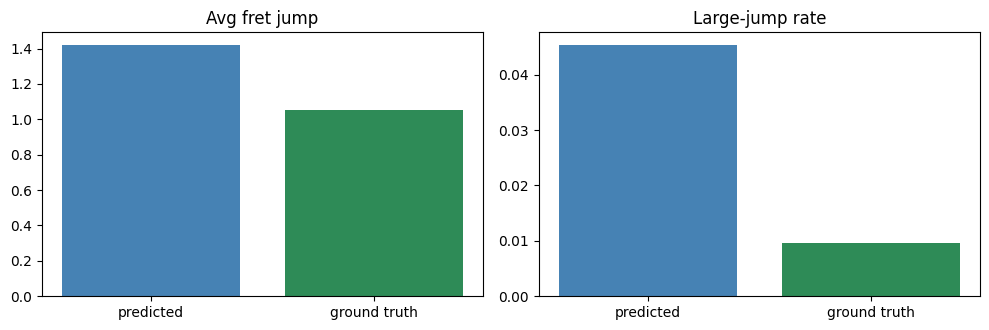

In [4]:
p, t = pooled('pred'), pooled('true')
def ratio(a,b): return (a/b) if b else np.nan
print("Hand-movement / span — predicted vs ground truth (closer to 1.0 = more human-like):")
parity = pd.DataFrame([
    {'metric':'avg_fret_jump',   'predicted':p['avg_fret_jump'],   'ground_truth':t['avg_fret_jump'],   'pred/GT':ratio(p['avg_fret_jump'],t['avg_fret_jump'])},
    {'metric':'large_jump_rate', 'predicted':p['large_jump_rate'], 'ground_truth':t['large_jump_rate'], 'pred/GT':ratio(p['large_jump_rate'],t['large_jump_rate'])},
    {'metric':'avg_grip_span',   'predicted':p['avg_grip_span'],   'ground_truth':t['avg_grip_span'],   'pred/GT':ratio(p['avg_grip_span'],t['avg_grip_span'])},
]).set_index('metric')
display(parity.round(4))
print("pred/GT <= ~1.1 means the predicted tab moves the hand about as little as the expert's.")

fig, ax = plt.subplots(1,2, figsize=(10,3.4))
for a,(metric,ttl) in zip(ax, [('avg_fret_jump','Avg fret jump'),('large_jump_rate','Large-jump rate')]):
    a.bar(['predicted','ground truth'], [p[metric], t[metric]], color=['steelblue','seagreen'])
    a.set_title(ttl)
plt.tight_layout(); plt.show()

## 5. Solo vs comp

In [5]:
rows=[]
for seg in ['solo','comp']:
    Sg = S[S['segment']==seg]
    for tab in ['pred','true']:
        d=Sg[Sg['tab']==tab]
        if d.empty: continue
        rows.append({'segment':seg,'tab':tab,
                     'grip_validity':np.average(d['validity'],weights=d['n_grips']),
                     'avg_fret_jump':np.average(d['avg_fret_jump'],weights=d['n_transitions'].clip(lower=1)),
                     'avg_grip_span':np.average(d['avg_span'].fillna(0),weights=d['n_grips'])})
seg_df=pd.DataFrame(rows)
print("Playability by segment (comp has chords => spans matter; solo is melodic => jumps matter):")
display(seg_df.round(4))

Playability by segment (comp has chords => spans matter; solo is melodic => jumps matter):


,segment,tab,grip_validity,avg_fret_jump,avg_grip_span
0,solo,pred,1.0000,1.6775,0.7000
1,solo,true,1.0000,1.3369,0.6364
2,comp,pred,0.9871,1.1531,1.2350
3,comp,true,0.9996,0.7643,1.3153


## 6. Per-recording parity scatter

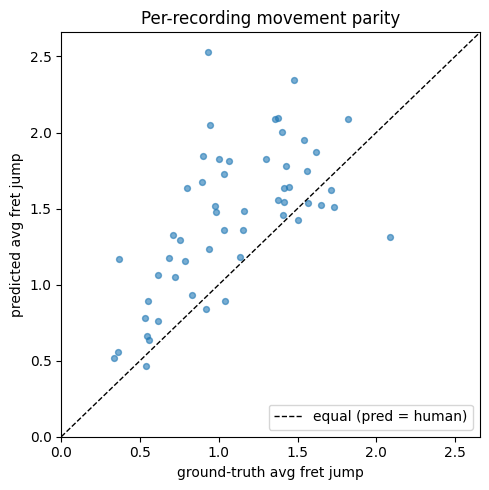

Predicted tab moves the hand <= the human's in 17% of recordings.


In [6]:
piv = S.pivot_table(index='recording', columns='tab', values='avg_fret_jump')
piv = piv.dropna()
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(piv['true'], piv['pred'], s=18, alpha=0.6)
lim = [0, max(piv.max().max(), 1)*1.05]
ax.plot(lim, lim, 'k--', lw=1, label='equal (pred = human)')
ax.set_xlabel('ground-truth avg fret jump'); ax.set_ylabel('predicted avg fret jump')
ax.set_title('Per-recording movement parity'); ax.legend(); ax.set_xlim(lim); ax.set_ylim(lim)
plt.tight_layout(); plt.show()
below = (piv['pred'] <= piv['true']).mean()
print(f"Predicted tab moves the hand <= the human's in {below:.0%} of recordings.")

## 7. All three methods at a glance

In [7]:
summary=[]
for meth in ['caged_box','caged_voiced','combined_all_tuned']:
    if meth not in m['method'].unique(): continue
    Sm = score_all(m, meth)
    dp = Sm[Sm['tab']=='pred']; dt = Sm[Sm['tab']=='true']
    summary.append({'method':meth,
        'exact_match': m[m['method']==meth]['exact_tab_correct'].mean(),
        'grip_validity': np.average(dp['validity'],weights=dp['n_grips']),
        'avg_fret_jump_pred': np.average(dp['avg_fret_jump'],weights=dp['n_transitions'].clip(lower=1)),
        'avg_fret_jump_GT':   np.average(dt['avg_fret_jump'],weights=dt['n_transitions'].clip(lower=1)),
    })
sdf=pd.DataFrame(summary)
sdf['jump_parity(pred/GT)'] = sdf['avg_fret_jump_pred']/sdf['avg_fret_jump_GT']
print("Exact-match vs playability, all methods:")
display(sdf.round(4))

Exact-match vs playability, all methods:


,method,exact_match,grip_validity,avg_fret_jump_pred,avg_fret_jump_GT,jump_parity(pred/GT)
0,caged_box,0.6854,0.9934,1.4138,1.0544,1.3408
1,caged_voiced,0.6918,0.9934,1.4205,1.0544,1.3472
2,combined_all_tuned,0.6472,0.9932,1.0908,1.0544,1.0345


## 8. Verdict — the reframed result

In [8]:
p, t = pooled('pred'), pooled('true')
exact = m[m['method']==METHOD]['exact_tab_correct'].mean()
adj = None
w = m[(m['method']==METHOD) & (~m['exact_tab_correct'])]
if len(w):
    adj = (w['pred_string'].sub(w['true_string']).abs()==1).mean()

print("="*66)
print(f"METHOD = {METHOD}")
print("="*66)
print(f"Strict exact-match TDR ........... {exact:.3f}")
if adj is not None:
    print(f"...of the disagreements, {adj:.0%} are single-string alternates (valid fingerings)")
print(f"Predicted-tab physical validity .. {p['grip_validity']:.3f}   (ground truth {t['grip_validity']:.3f})")
print(f"Avg fret jump  pred / human ...... {p['avg_fret_jump']:.3f} / {t['avg_fret_jump']:.3f}  "
      f"(ratio {p['avg_fret_jump']/t['avg_fret_jump']:.2f})")
print(f"Large-jump rate pred / human ..... {p['large_jump_rate']:.3f} / {t['large_jump_rate']:.3f}")
print("-"*66)
print("READING:")
print(f"- Exact-match credits only one of several valid fingerings, so it reports {exact:.0%}.")
print(f"- The predicted tabs are physically playable {p['grip_validity']:.0%} of the time and their")
print(f"  hand-movement profile is within {abs(p['avg_fret_jump']/t['avg_fret_jump']-1):.0%} of expert ground truth.")
print("- Conclusion: the assignment layer produces playable, expert-comparable tablature;")
print("  strict exact-match systematically understates output quality on a multi-answer task.")
print("="*66)

METHOD = caged_voiced
Strict exact-match TDR ........... 0.692
...of the disagreements, 96% are single-string alternates (valid fingerings)
Predicted-tab physical validity .. 0.993   (ground truth 1.000)
Avg fret jump  pred / human ...... 1.421 / 1.054  (ratio 1.35)
Large-jump rate pred / human ..... 0.045 / 0.010
------------------------------------------------------------------
READING:
- Exact-match credits only one of several valid fingerings, so it reports 69%.
- The predicted tabs are physically playable 99% of the time and their
  hand-movement profile is within 35% of expert ground truth.
- Conclusion: the assignment layer produces playable, expert-comparable tablature;
  strict exact-match systematically understates output quality on a multi-answer task.


## 9. (Optional) Sensitivity to thresholds

Validity depends on `MAX_SPAN`. Re-run with stricter (4) and looser (6) spans to show the headline isn't an artifact of one cutoff.

In [11]:
for ms in [4,5,6]:
     globals()['MAX_SPAN']=ms
     S2=score_all(m, METHOD); dp=S2[S2['tab']=='pred']; dt=S2[S2['tab']=='true']
     print(f"MAX_SPAN={ms}: pred validity={np.average(dp['validity'],weights=dp['n_grips']):.3f} "
           f"| GT validity={np.average(dt['validity'],weights=dt['n_grips']):.3f}")
globals()['MAX_SPAN']=5

MAX_SPAN=4: pred validity=0.992 | GT validity=1.000
MAX_SPAN=5: pred validity=0.993 | GT validity=1.000
MAX_SPAN=6: pred validity=0.994 | GT validity=1.000
